# Task 1 – Structured Financial Time Series Analysis

This notebook is structured to answer Task 1 in four parts:

1. **Individual series (patterns)**
2. **Relationships between series**
3. **Grouping / clustering**
4. **Critical insights**

The notebook uses a **consistent color mapping** so that each series keeps the same color in every plot.


In [ ]:
# =========================
# 1. Imports and setup
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

sns.set_theme(style="whitegrid")

# Mount Google Drive
drive.mount('/content/drive')

# Read data
path = "/content/drive/MyDrive/TMS088   MSA410 Financial time series/"
pictures = "/content/drive/MyDrive/TMS088   MSA410 Financial time series/Pictures/"
df = pd.read_csv(path + "spiff_data-2.csv")

# Clean columns
df.columns = df.columns.str.strip()
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Set day as index if available
if "day" in df.columns:
    df = df.set_index("day")

print("Shape:", df.shape)
print("Columns:", list(df.columns))

Mounted at /content/drive
Shape: (5456, 7)
Columns: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']


In [ ]:
# =========================
# 2. Consistent colors for all series
# =========================

palette = sns.color_palette("tab10", n_colors=len(df.columns))
series_colors = dict(zip(df.columns, palette))

series_colors

{'gurkor': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'guitars': (1.0, 0.4980392156862745, 0.054901960784313725),
 'slingshots': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'stocks': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'sugar': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'water': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'tranquillity': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)}

## Part 1 – Individual series (patterns)

Focus:
- trend
- volatility
- stationarity
- distribution
- outlier handling


Missing values per series:


,missing_count
gurkor,250
guitars,250
slingshots,250
stocks,250
sugar,250
water,250
tranquillity,250


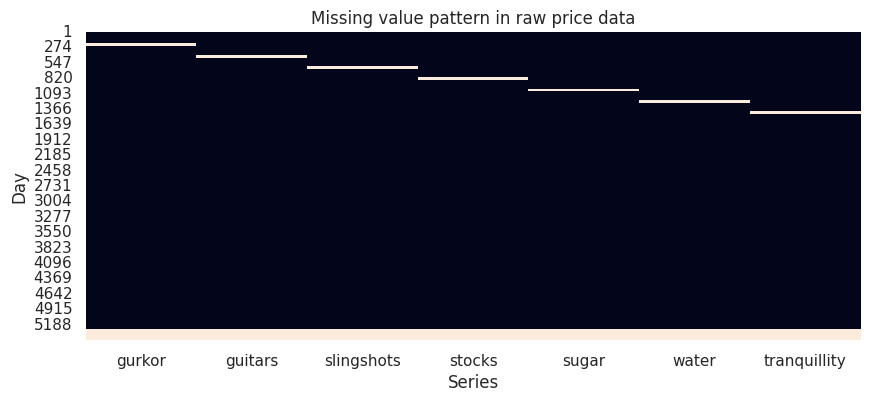

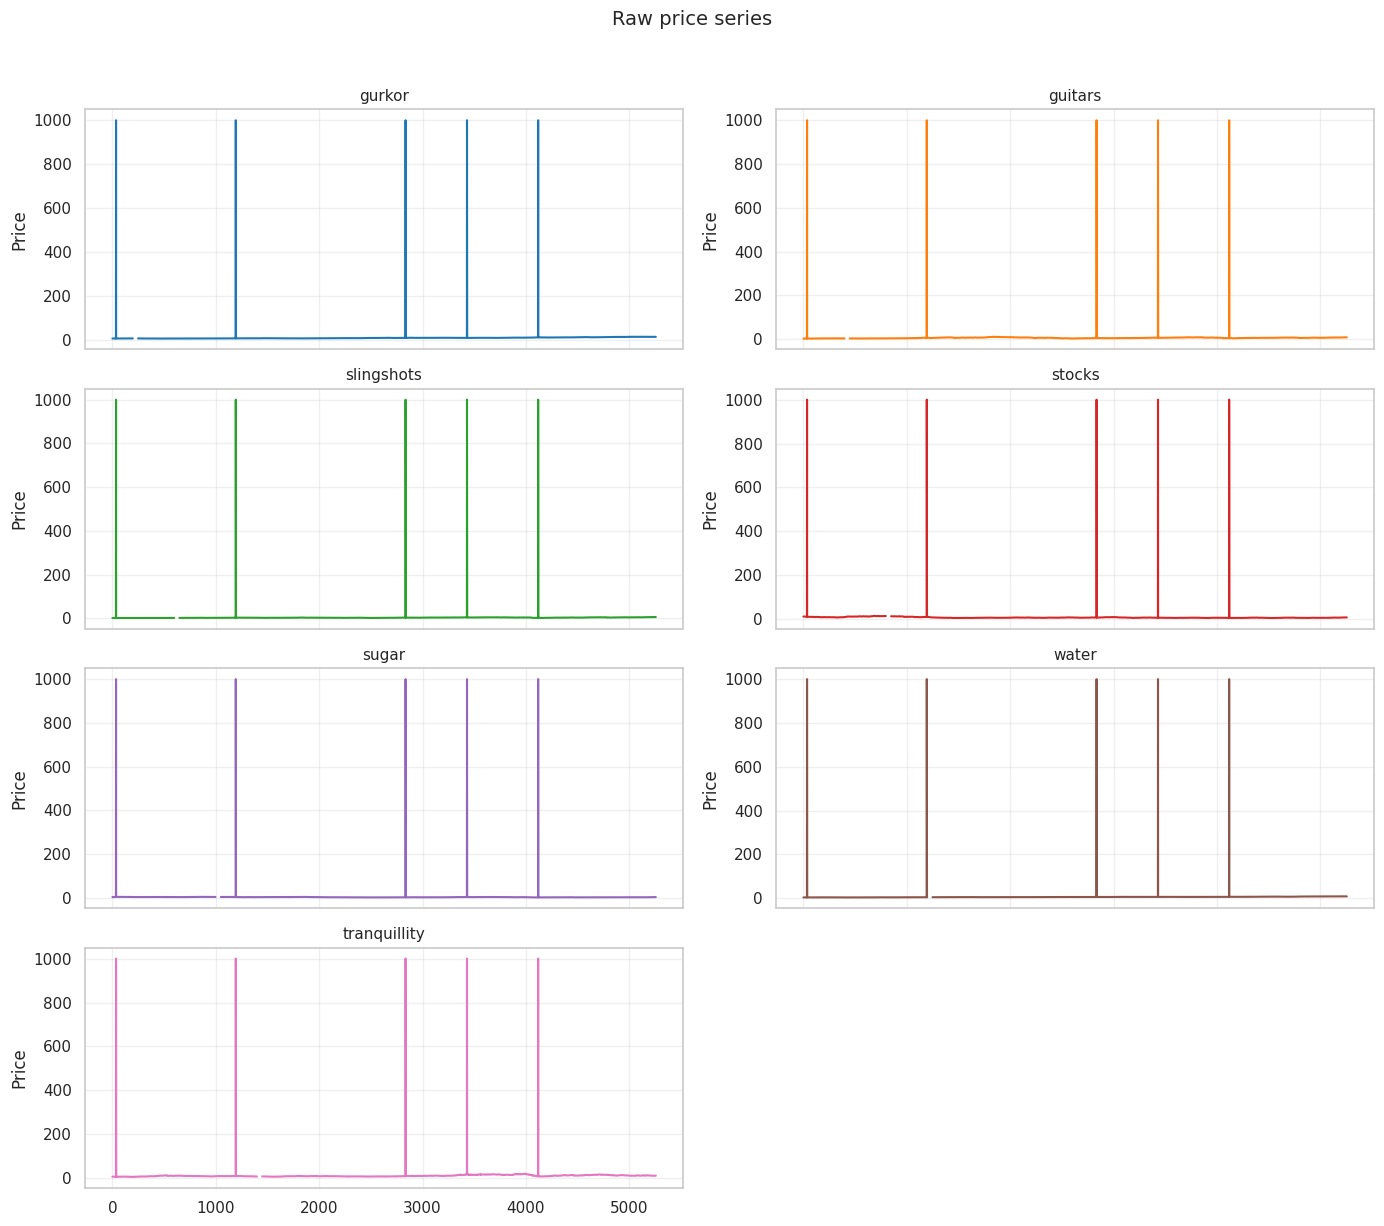

In [ ]:
# =========================
# 3. Initial overview
# =========================

print("Missing values per series:")
display(df.isna().sum().to_frame("missing_count"))

plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing value pattern in raw price data")
plt.xlabel("Series")
plt.ylabel("Day")
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], color=series_colors[col], linewidth=1.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Price")
    axes[i].grid(alpha=0.3)

for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw price series", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Extreme observations removed per series (|z| > 5 on price levels):


,removed_count
gurkor,5
guitars,5
slingshots,5
stocks,5
sugar,5
water,5
tranquillity,5


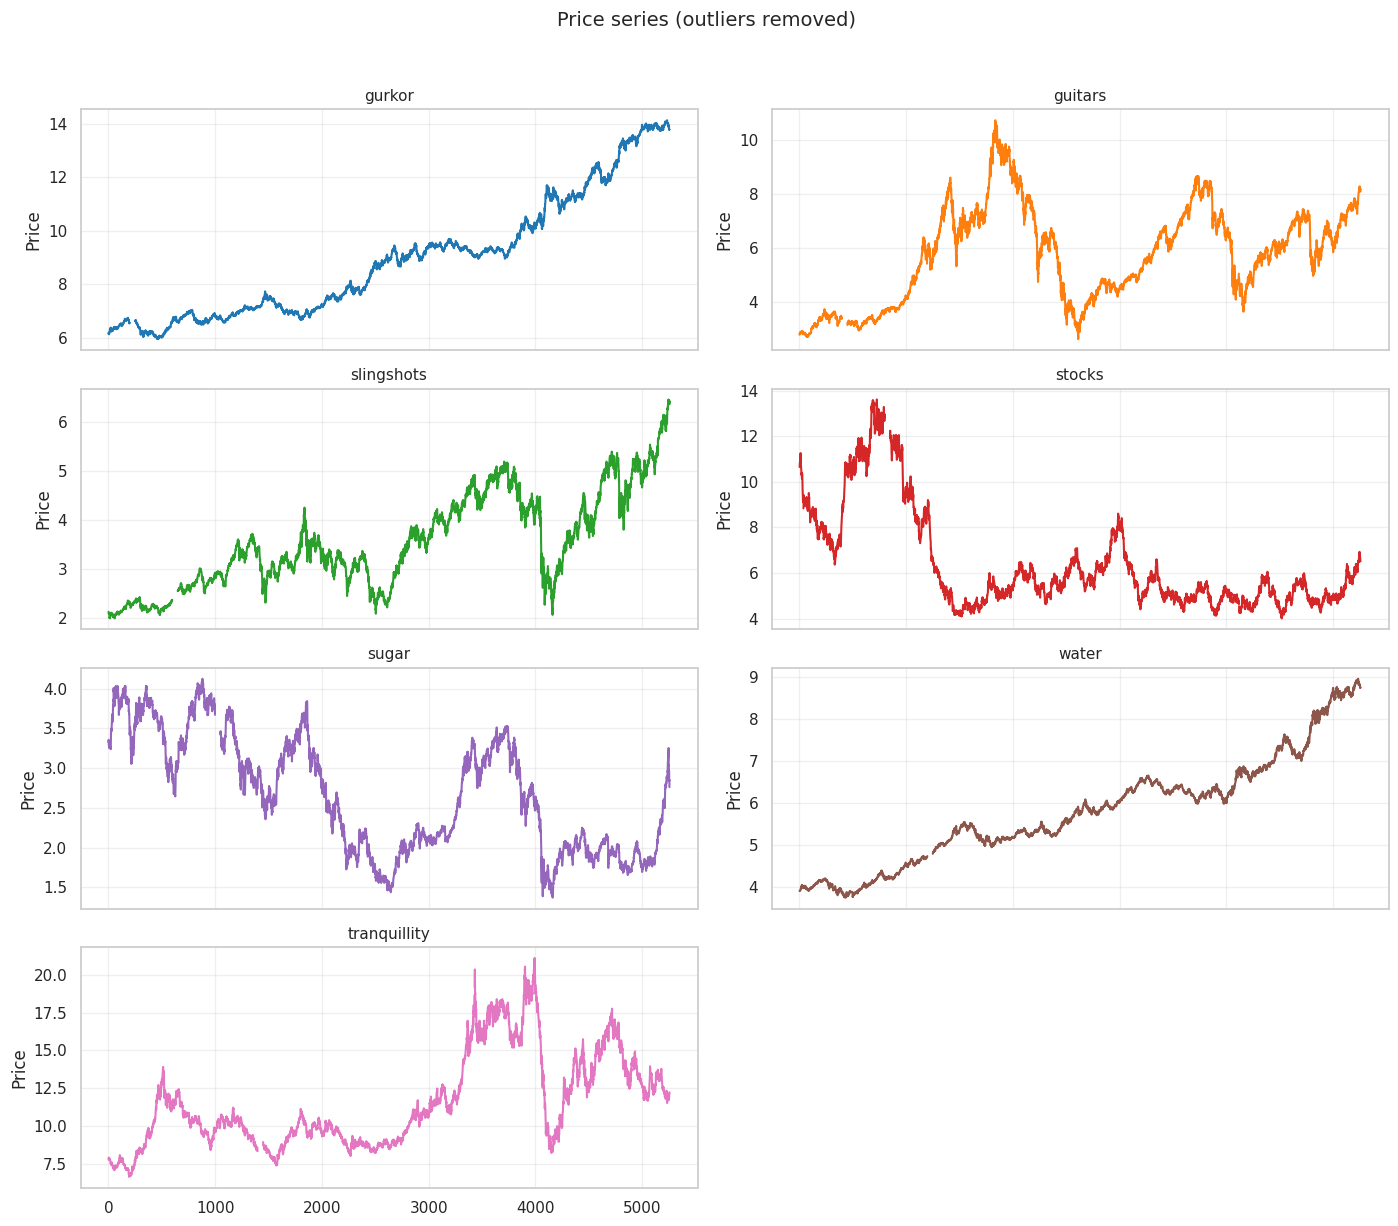

In [ ]:
# =========================
# 4. Clean extreme spikes on price levels
# =========================

price_z = (df - df.mean()) / df.std()
prices_clean = df.mask(np.abs(price_z) > 5)

print("Extreme observations removed per series (|z| > 5 on price levels):")
display((np.abs(price_z) > 5).sum().to_frame("removed_count"))

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, col in enumerate(prices_clean.columns):
    axes[i].plot(prices_clean.index, prices_clean[col], color=series_colors[col], linewidth=1.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Price")
    axes[i].grid(alpha=0.3)

for j in range(len(prices_clean.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Price series (outliers removed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

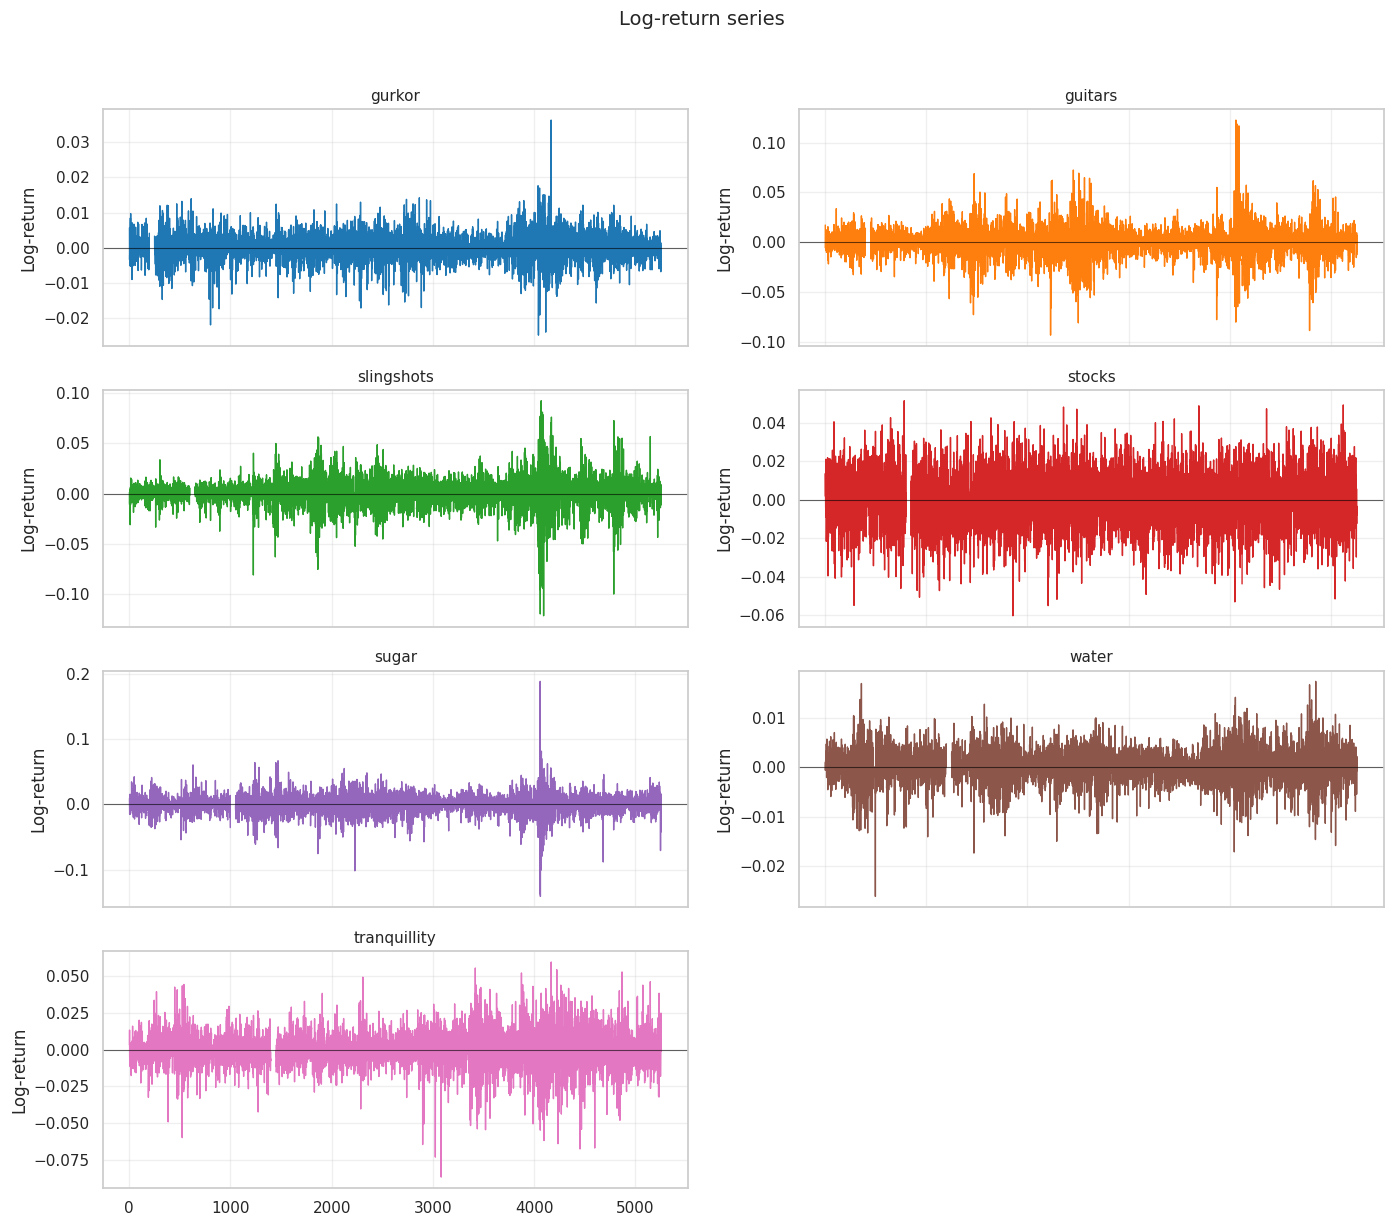

In [ ]:
# =========================
# 5. Log-returns from prices
# =========================

log_returns_clean = np.log(prices_clean / prices_clean.shift(1))

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, col in enumerate(log_returns_clean.columns):
    axes[i].plot(log_returns_clean.index, log_returns_clean[col], color=series_colors[col], linewidth=1.0)
    axes[i].axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Log-return")
    axes[i].grid(alpha=0.3)

for j in range(len(log_returns_clean.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Log-return series", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

,mean,std,skew,kurtosis
sugar,-0.000014,0.015209,-0.238585,10.704963
stocks,-0.000074,0.014935,-0.124211,0.077238
guitars,0.000236,0.014876,-0.034939,5.558723
slingshots,0.000194,0.014747,-0.444992,6.438702
tranquillity,0.000078,0.012589,-0.271848,2.976584
gurkor,0.000155,0.003945,-0.146980,3.517657
water,0.000152,0.003515,-0.259686,2.250074


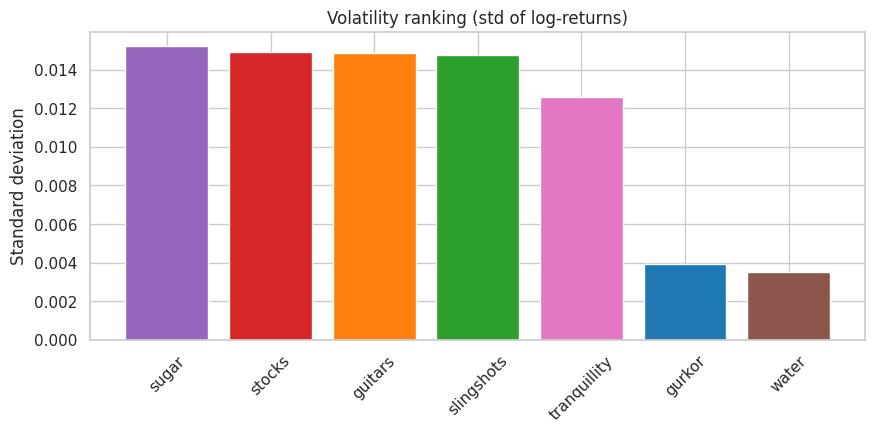

In [ ]:
# =========================
# 6. Descriptive statistics for log-returns
# =========================

stats = pd.DataFrame({
    "mean": log_returns_clean.mean(),
    "std": log_returns_clean.std(),
    "skew": log_returns_clean.skew(),
    "kurtosis": log_returns_clean.kurt()
}).sort_values("std", ascending=False)

display(stats)

plt.figure(figsize=(10, 4))
plt.bar(stats.index, stats["std"], color=[series_colors[c] for c in stats.index])
plt.title("Volatility ranking (std of log-returns)")
plt.ylabel("Standard deviation")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# =========================
# 7. Stationarity tests (ADF)
# =========================

adf_rows = []

for col in prices_clean.columns:
    p_price = adfuller(prices_clean[col].dropna())[1]
    p_ret = adfuller(log_returns_clean[col].dropna())[1]
    adf_rows.append({
        "series": col,
        "ADF p-value (prices)": p_price,
        "ADF p-value (log-returns)": p_ret
    })

adf_table = pd.DataFrame(adf_rows).set_index("series")
display(adf_table)

,ADF p-value (prices),ADF p-value (log-returns)
series,,
gurkor,0.990505,0.000000e+00
guitars,0.264574,1.322904e-22
slingshots,0.780331,0.000000e+00
stocks,0.171759,0.000000e+00
sugar,0.321888,0.000000e+00
water,0.991424,0.000000e+00
tranquillity,0.191635,0.000000e+00


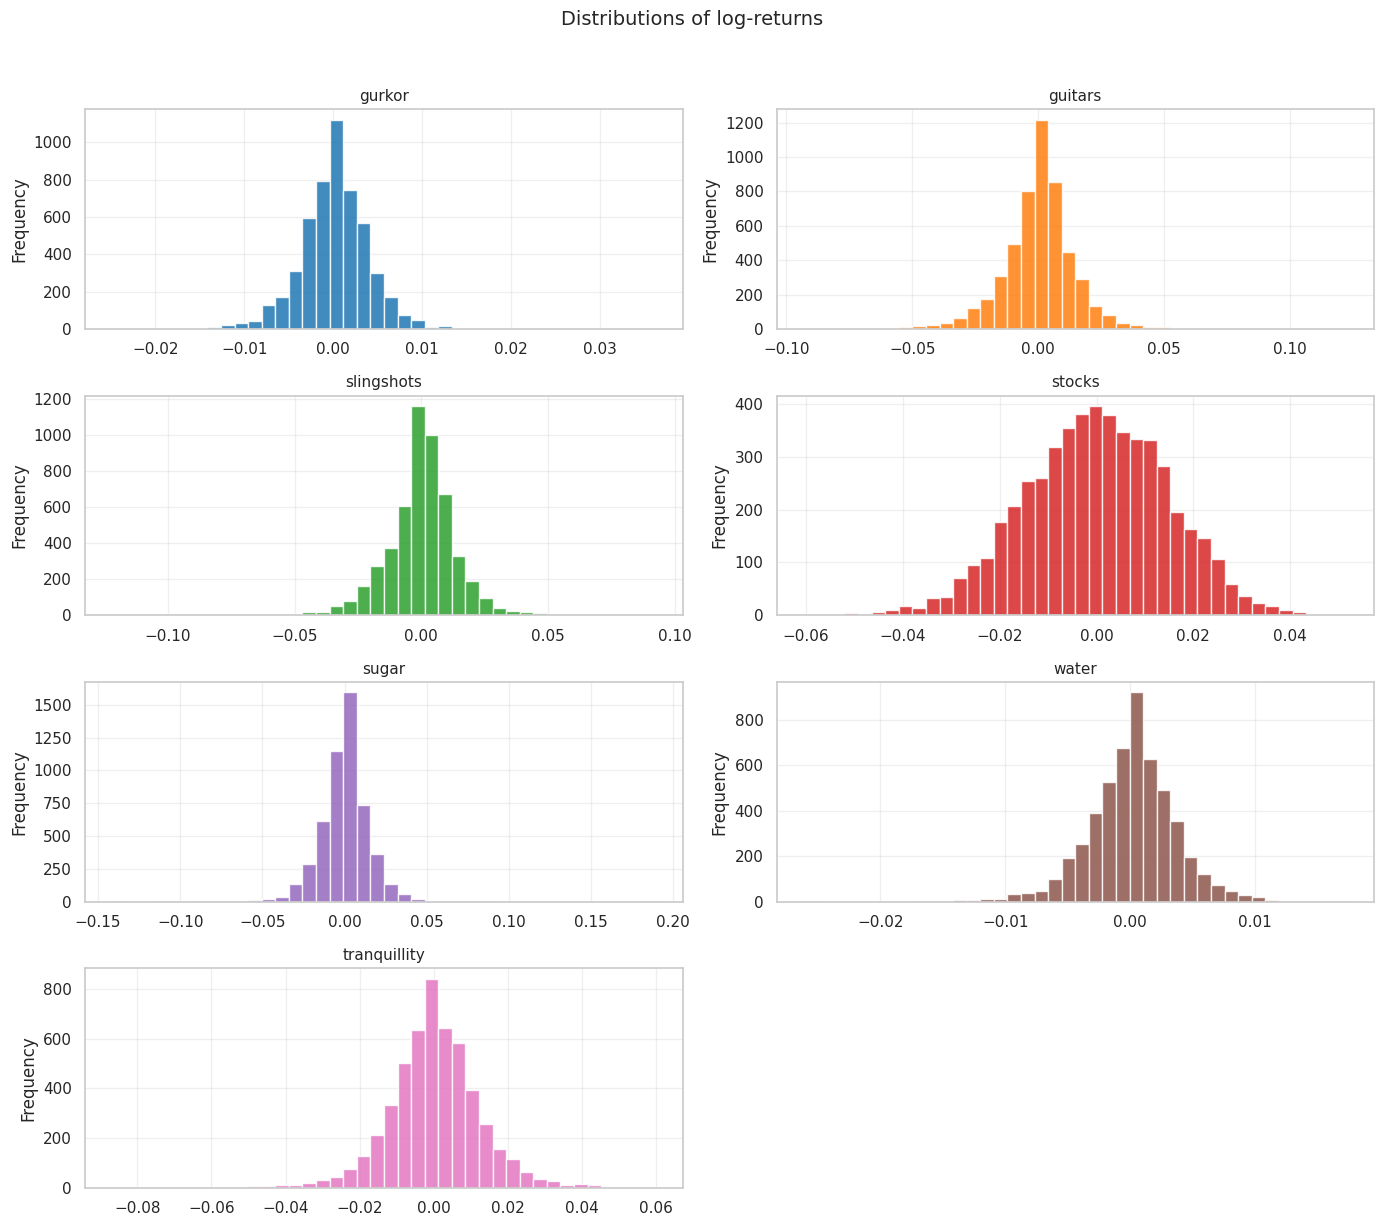

In [ ]:
# =========================
# 8. Distribution plots for log-returns
# =========================

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(log_returns_clean.columns):
    valid = log_returns_clean[col].dropna()
    axes[i].hist(valid, bins=40, color=series_colors[col], alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.3)

for j in range(len(log_returns_clean.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions of log-returns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Part 2 – Relationships between series

Focus:
- correlation
- co-movement
- comparison on return series


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000000,-0.241075,-0.216712,-0.041636,-0.066739,0.573293,-0.137819
guitars,-0.241075,1.000000,0.526253,0.016316,0.211811,-0.226021,0.223933
slingshots,-0.216712,0.526253,1.000000,0.013391,0.118452,-0.201113,0.188563
stocks,-0.041636,0.016316,0.013391,1.000000,-0.015689,-0.042117,0.010027
sugar,-0.066739,0.211811,0.118452,-0.015689,1.000000,-0.071434,0.126743
water,0.573293,-0.226021,-0.201113,-0.042117,-0.071434,1.000000,-0.157992
tranquillity,-0.137819,0.223933,0.188563,0.010027,0.126743,-0.157992,1.000000


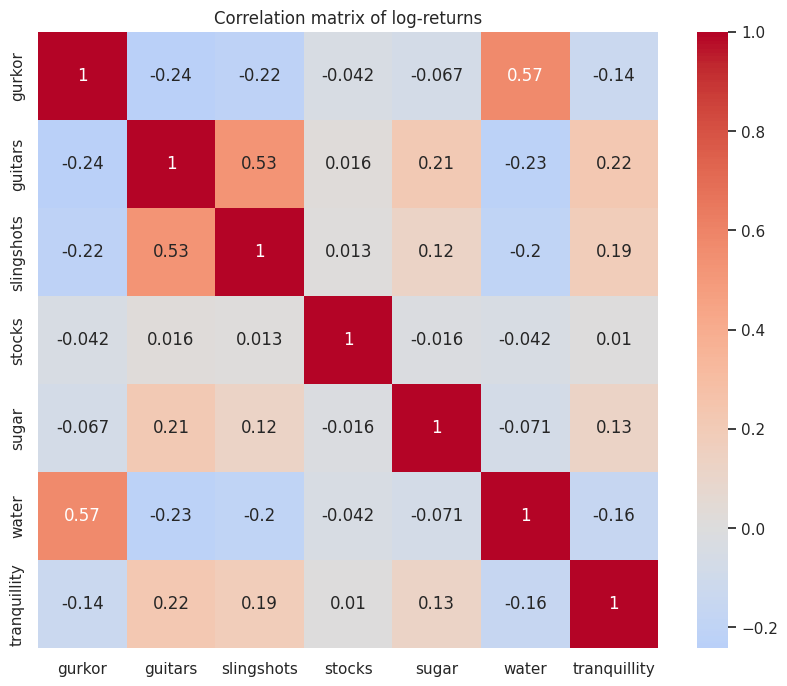

In [ ]:
# =========================
# 9. Correlation matrix of log-returns
# =========================

corr_returns = log_returns_clean.corr()
display(corr_returns)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_returns, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix of log-returns")
plt.savefig(pictures + "Correlation matrix of log-returns.jpg", dpi=300, bbox_inches="tight")
plt.show()

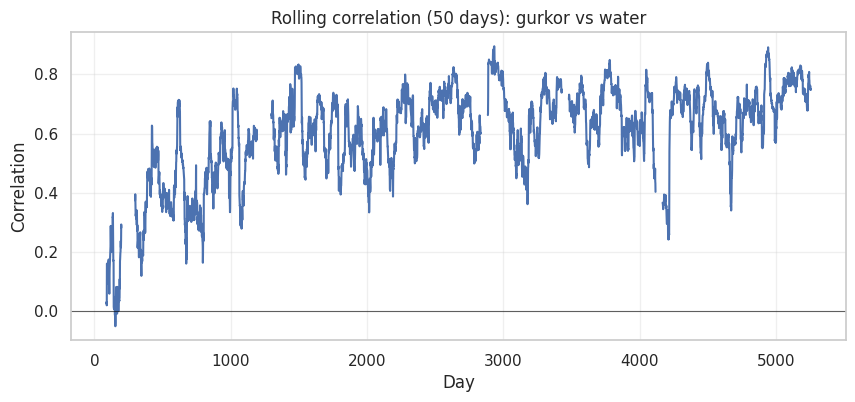

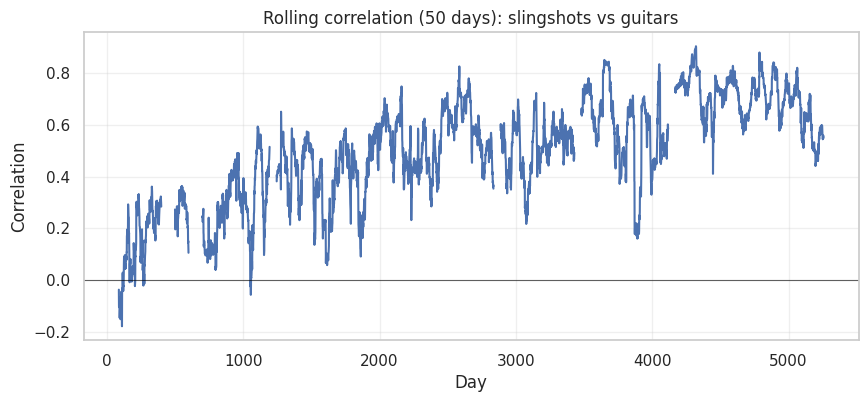

In [ ]:
window = 50

selected_pairs = [
    ("gurkor", "water"),
    ("slingshots", "guitars")
]

for a, b in selected_pairs:
    rolling_corr = log_returns_clean[a].rolling(window).corr(log_returns_clean[b])

    plt.figure(figsize=(10,4))
    plt.plot(rolling_corr, linewidth=1.5)
    plt.axhline(0, color="black", linewidth=0.8, alpha=0.6)

    plt.title(f"Rolling correlation ({window} days): {a} vs {b}")
    plt.ylabel("Correlation")
    plt.xlabel("Day")
    plt.grid(alpha=0.3)

    filename = f"rolling_corr_{a}_{b}.jpg"
    plt.savefig(pictures + filename, dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
# =========================
# 10. Pairwise co-movement overview
# =========================

top_pairs = (
    corr_returns.where(~np.eye(len(corr_returns), dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print("Strongest positive correlations:")
display(top_pairs.head(10).to_frame("correlation"))

print("Strongest negative correlations:")
display(top_pairs.tail(10).to_frame("correlation"))

Strongest positive correlations:


correlation
gurkor       water            0.573293
water        gurkor           0.573293
slingshots   guitars          0.526253
guitars      slingshots       0.526253
             tranquillity     0.223933
tranquillity guitars          0.223933
guitars      sugar            0.211811
sugar        guitars          0.211811
tranquillity slingshots       0.188563
slingshots   tranquillity     0.188563

Strongest negative correlations:


correlation
tranquillity water           -0.157992
water        tranquillity    -0.157992
             slingshots      -0.201113
slingshots   water           -0.201113
gurkor       slingshots      -0.216712
slingshots   gurkor          -0.216712
guitars      water           -0.226021
water        guitars         -0.226021
guitars      gurkor          -0.241075
gurkor       guitars         -0.241075

## Part 3 – Grouping / clustering

Focus:
- clusters based on similarity
- economic interpretation


In [ ]:
# =========================
# 11. Hierarchical clustering based on return correlations
# =========================

distance_matrix = 1 - corr_returns
condensed_dist = squareform(distance_matrix.fillna(0).values, checks=False)
Z = linkage(condensed_dist, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=corr_returns.columns.tolist(), leaf_rotation=45)
plt.title("Hierarchical clustering based on return correlations")
plt.ylabel("Distance = 1 - correlation")
plt.show()

## Part 4 – Critical insights

Focus:
- what the analysis suggests
- what is uncertain
- how this guides Tasks 2 and 3


In [ ]:
# =========================
# 12. Ljung-Box tests for serial dependence
# =========================

lb_rows = []

for col in log_returns_clean.columns:
    ret = log_returns_clean[col].dropna()
    sq_ret = (ret ** 2).dropna()

    lb_ret_p = acorr_ljungbox(ret, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    lb_sq_p = acorr_ljungbox(sq_ret, lags=[10], return_df=True)["lb_pvalue"].iloc[0]

    lb_rows.append({
        "series": col,
        "Ljung-Box p-value (returns, lag 10)": lb_ret_p,
        "Ljung-Box p-value (squared returns, lag 10)": lb_sq_p
    })

lb_table = pd.DataFrame(lb_rows).set_index("series")
display(lb_table)

,"Ljung-Box p-value (returns, lag 10)","Ljung-Box p-value (squared returns, lag 10)"
series,,
gurkor,6.861252e-03,3.590312e-72
guitars,5.753211e-03,0.000000e+00
slingshots,6.095996e-10,0.000000e+00
stocks,9.345101e-01,7.105471e-01
sugar,2.652255e-04,0.000000e+00
water,1.159058e-01,1.104060e-93
tranquillity,2.915877e-01,9.386927e-136


In [ ]:
# =========================
# 13. Report-ready summary table
# =========================

summary_table = stats.join(adf_table).join(lb_table)
display(summary_table)

,mean,std,skew,kurtosis,ADF p-value (cleaned prices),ADF p-value (cleaned log-returns),"Ljung-Box p-value (returns, lag 10)","Ljung-Box p-value (squared returns, lag 10)"
sugar,-0.000014,0.015209,-0.238585,10.704963,0.321888,0.000000e+00,2.652255e-04,0.000000e+00
stocks,-0.000074,0.014935,-0.124211,0.077238,0.171759,0.000000e+00,9.345101e-01,7.105471e-01
guitars,0.000236,0.014876,-0.034939,5.558723,0.264574,1.322904e-22,5.753211e-03,0.000000e+00
slingshots,0.000194,0.014747,-0.444992,6.438702,0.780331,0.000000e+00,6.095996e-10,0.000000e+00
tranquillity,0.000078,0.012589,-0.271848,2.976584,0.191635,0.000000e+00,2.915877e-01,9.386927e-136
gurkor,0.000155,0.003945,-0.146980,3.517657,0.990505,0.000000e+00,6.861252e-03,3.590312e-72
water,0.000152,0.003515,-0.259686,2.250074,0.991424,0.000000e+00,1.159058e-01,1.104060e-93


## Suggested report discussion

Use your actual outputs to discuss points such as:

- Several raw price series contain extreme spikes, which likely reflect data issues or placeholders rather than genuine market moves.
- After cleaning, the price series become interpretable and the return series fluctuate around zero.
- Volatility differs across assets, which suggests heterogeneous risk profiles.
- The kurtosis values indicate heavy tails, which is common in financial time series.
- Correlation patterns in returns can reveal which markets move together and which behave more independently.
- Clustering helps identify groups of similar assets and supports economic interpretation.
- Ljung–Box results on returns and squared returns can indicate whether there is serial dependence or volatility clustering.
- These insights should later guide interpolation (Task 2) and extrapolation (Task 3).
